In [1]:
%load_ext autoreload
%autoreload 2

In [47]:
# Typical ML python packages
import os
import sys
import numpy as np
import tensorflow as tf
import scipy
import sklearn
from sklearn.gaussian_process import GaussianProcessClassifier
import matplotlib as mpl
import matplotlib.pyplot as plt
import hyperspy.api_nogui as hs
import seaborn as sn
import pandas as pd

In [3]:
# Custom dualVAE package
from logicalEELS.preprocess import loadDirDM4, findEdgeIndex, alignSpectra, backgroundSubtract, normAUC_inds
from logicalEELS.models import createDualVAE
from logicalEELS.plot import plotSpectra, plot_SI_class

In [49]:
# Confirm verions and CUDA availibility
print('Python Version', sys.version)
print('Numpy Version', np.__version__)
print('Scipy Version', scipy.__version__)
print('Hyperspy Version', hs.__version__)
print('Sci-Kit Learn Version', sklearn.__version__)
print('Tensorflow version', tf.__version__)
print('Is built with CUDA:', tf.test.is_built_with_cuda())
print('GPU:', tf.config.list_physical_devices('GPU'))

Python Version 3.10.15 | packaged by conda-forge | (main, Oct 16 2024, 01:24:24) [GCC 13.3.0]
Numpy Version 1.26.4
Scipy Version 1.14.1
Hyperspy Version 1.7.3
Sci-Kit Learn Version 1.5.2
Tensorflow version 2.17.0
Is built with CUDA: False
GPU: []


In [5]:
tf.random.set_seed(42)
np.random.seed(42)

In [6]:
# Define the locations of the data and model directories
DATA_DIR = 'data'
MODEL_DIR = 'models'

In [7]:
# DM4 File Locations C:\Users\holle\Documents\JHU\Data\EELS_Data\\MXene_Inprocess
path_raw = 'data/MXene_Raw_Rebin_Aligned_All'
path_pca = 'data/MXene_PCA_Rebin_Aligned_All'

In [8]:
energy_axis, spectra_raw, filenames_raw = loadDirDM4(path_raw, crop=(390.0, 790.0))

Files found: 24


Loading 500C_Area4_Raw_Aligned.dm4...
(570, 1600)
Loading 600C_Area4_Raw_Aligned.dm4...
(570, 1600)
Loading 300C_Area4_Raw_Aligned.dm4...


(570, 1600)
Loading 600C_Area1_Raw_Aligned.dm4...
(570, 1600)
Loading 300C_Area3_Raw_Aligned.dm4...
(570, 1600)
Loading 400C_Area1_Raw_Aligned.dm4...


(570, 1600)
Loading 700C_Area1_Raw_Aligned.dm4...
(570, 1600)
Loading 800C_Area4_Raw_Aligned.dm4...
(570, 1600)
Loading 500C_Area3_Raw_Aligned.dm4...


(570, 1600)
Loading 200C_Area4_Raw_Aligned.dm4...


(570, 1600)
Loading Initial_Area4_Raw_Aligned.dm4...
(570, 1600)
Loading 200C_Area3_Raw_Aligned.dm4...
(570, 1600)
Loading 600C_Area3_Raw_Aligned.dm4...


(570, 1600)
Loading 700C_Area3_Raw_Aligned.dm4...
(570, 1600)
Loading 400C_Area4_Raw_Aligned.dm4...
(570, 1600)
Loading 800C_Area1_Raw_Aligned.dm4...


(570, 1600)
Loading 800C_Area3_Raw_Aligned.dm4...
(570, 1600)
Loading 500C_Area1_Raw_Aligned.dm4...
(570, 1600)
Loading 300C_Area1_Raw_Aligned.dm4...


(570, 1600)
Loading 200C_Area1_Raw_Aligned.dm4...
(570, 1600)
Loading 400C_Area3_Raw_Aligned.dm4...
(570, 1600)
Loading Initial_Area1_Raw_Aligned.dm4...


(570, 1600)
Loading Initial_Area3_Raw_Aligned.dm4...
(570, 1600)
Loading 700C_Area4_Raw_Aligned.dm4...
(570, 1600)


In [9]:
_, spectra_pca, filenames_pca = loadDirDM4(path_pca, crop=(390.0, 790.0))

Files found: 24
Loading Initial_Area3_PCA_Aligned.dm4...
(570, 1600)
Loading 500C_Area3_PCA_Aligned.dm4...


(570, 1600)
Loading 200C_Area4_PCA_Aligned.dm4...
(570, 1600)
Loading 400C_Area3_PCA_Aligned.dm4...
(570, 1600)
Loading Initial_Area1_PCA_Aligned.dm4...


(570, 1600)
Loading 300C_Area4_PCA_Aligned.dm4...
(570, 1600)
Loading 200C_Area3_PCA_Aligned.dm4...
(570, 1600)
Loading 200C_Area1_PCA_Aligned.dm4...


(570, 1600)
Loading 400C_Area4_PCA_Aligned.dm4...
(570, 1600)
Loading 300C_Area1_PCA_Aligned.dm4...
(570, 1600)
Loading 600C_Area1_PCA_Aligned.dm4...


(570, 1600)
Loading 600C_Area4_PCA_Aligned.dm4...
(570, 1600)
Loading 800C_Area1_PCA_Aligned.dm4...
(570, 1600)
Loading 600C_Area3_PCA_Aligned.dm4...


(570, 1600)
Loading 700C_Area3_PCA_Aligned.dm4...
(570, 1600)
Loading 800C_Area4_PCA_Aligned.dm4...
(570, 1600)
Loading 700C_Area4_PCA_Aligned.dm4...


(570, 1600)
Loading 700C_Area1_PCA_Aligned.dm4...
(570, 1600)
Loading Initial_Area4_PCA_Aligned.dm4...
(570, 1600)
Loading 500C_Area1_PCA_Aligned.dm4...


(570, 1600)
Loading 500C_Area4_PCA_Aligned.dm4...
(570, 1600)
Loading 400C_Area1_PCA_Aligned.dm4...
(570, 1600)
Loading 800C_Area3_PCA_Aligned.dm4...


(570, 1600)
Loading 300C_Area3_PCA_Aligned.dm4...
(570, 1600)


In [10]:
print('Spectra Shapes:')
print('Raw (SIs, pixels, eV bins):', spectra_raw.shape)
print('PCA (SIs, pixels, eV bins):', spectra_pca.shape)
print('Axis (start, step, stop)  :',energy_axis[0], energy_axis[1]-energy_axis[0], energy_axis[-1])

Spectra Shapes:
Raw (SIs, pixels, eV bins): (24, 570, 1600)
PCA (SIs, pixels, eV bins): (24, 570, 1600)
Axis (start, step, stop)  : 390.0 0.25 789.75


In [11]:
ind_Cr = findEdgeIndex(energy_axis, 567.5, 627.5)
ind_F = findEdgeIndex(energy_axis, 677.0, 737.0)
ind_O = findEdgeIndex(energy_axis, 516.5, 570)

In [12]:
aligned_spectra_raw = alignSpectra(energy_axis, spectra_raw, ind_Cr, 570, 570)
aligned_spectra_pca = alignSpectra(energy_axis, spectra_pca, ind_Cr, 570, 570)

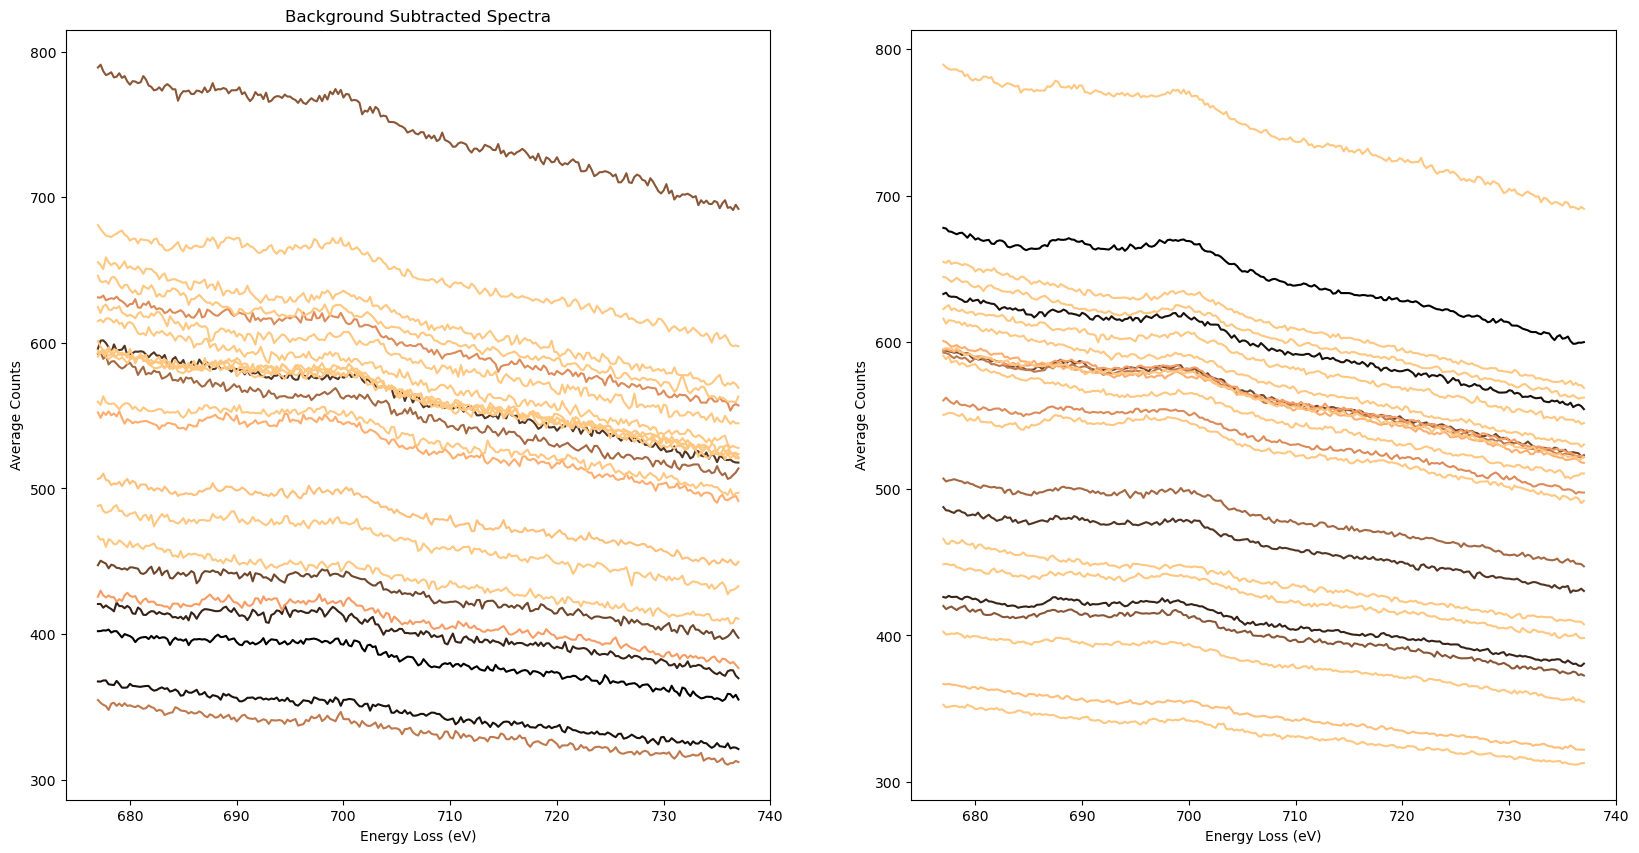

In [56]:
energy_axis_F = energy_axis[ind_F]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))
plotSpectra(ax1, energy_axis_F, aligned_spectra_raw[:,:, ind_F], title='Background Subtracted Spectra', )
plotSpectra(ax2, energy_axis_F, aligned_spectra_pca[:,:, ind_F])
plt.show()

In [28]:
ind_norm = findEdgeIndex(energy_axis, 570.0, 592.5)

aligned_norm_spectra_raw = normAUC_inds(energy_axis, aligned_spectra_raw, ind_norm)
aligned_norm_spectra_pca = normAUC_inds(energy_axis, aligned_spectra_pca, ind_norm)

(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)
(100, 241)


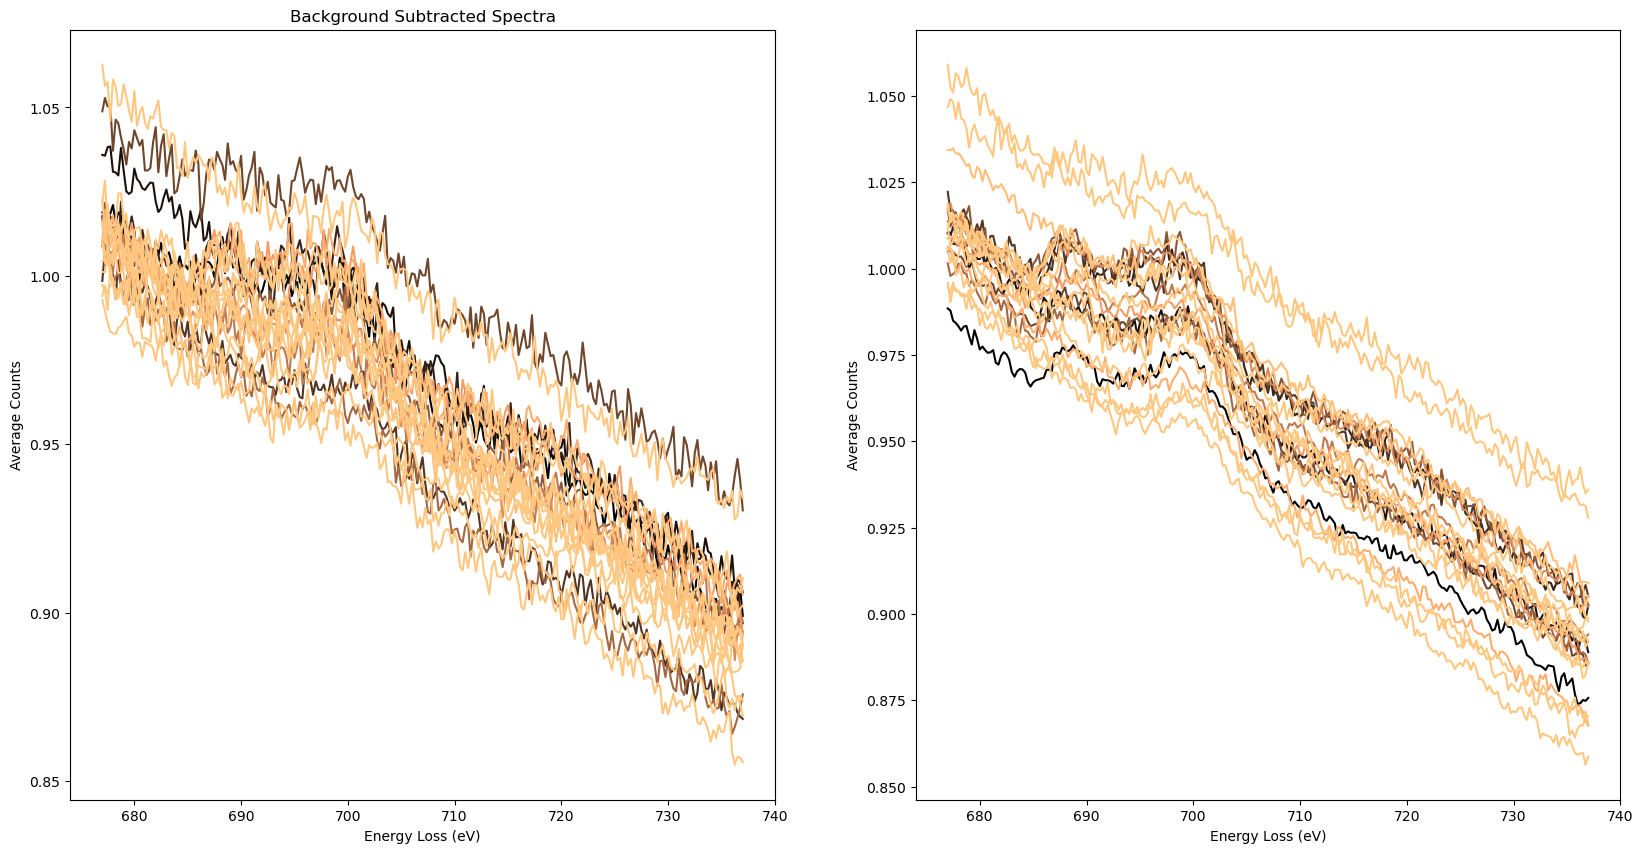

In [83]:
energy_axis_F = energy_axis[ind_F]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))
plotSpectra(ax1, energy_axis_F, aligned_norm_spectra_raw[:,:, ind_F], title='Background Subtracted Spectra', )
plotSpectra(ax2, energy_axis_F, aligned_norm_spectra_pca[:,:, ind_F])
plt.show()

In [67]:
ind_F_fit = findEdgeIndex(energy_axis, 650, 680)
print('Fit raw data')
backSub_nCr_F_raw = backgroundSubtract(energy_axis, aligned_norm_spectra_raw, ind_F, ind_F_fit)
print('fit PCA data')
backSub_nCr_F_pca = backgroundSubtract(energy_axis, aligned_norm_spectra_pca, ind_F, ind_F_fit)

Fit raw data
Fitting Img: 0
Fitting Img: 1
Fitting Img: 2
Fitting Img: 3
Fitting Img: 4
Fitting Img: 5
Fitting Img: 6
Fitting Img: 7
Fitting Img: 8
Fitting Img: 9
Fitting Img: 10
Fitting Img: 11
Fitting Img: 12
Fitting Img: 13
Fitting Img: 14
Fitting Img: 15
Fitting Img: 16
Fitting Img: 17
Fitting Img: 18
Fitting Img: 19
Fitting Img: 20
Fitting Img: 21
Fitting Img: 22
Fitting Img: 23
fit PCA data
Fitting Img: 0
Fitting Img: 1
Fitting Img: 2
Fitting Img: 3
Fitting Img: 4
Fitting Img: 5
Fitting Img: 6
Fitting Img: 7
Fitting Img: 8
Fitting Img: 9
Fitting Img: 10
Fitting Img: 11
Fitting Img: 12
Fitting Img: 13
Fitting Img: 14
Fitting Img: 15
Fitting Img: 16
Fitting Img: 17
Fitting Img: 18
Fitting Img: 19
Fitting Img: 20
Fitting Img: 21
Fitting Img: 22
Fitting Img: 23


In [78]:
ind_F, ind_F_fit

(slice(1148, 1389, 1), slice(1040, 1161, 1))

In [77]:
backSub_nCr_F_raw.shape

(24, 570, 241)

In [79]:
1148-1389

-241

In [76]:
1161-1040

121

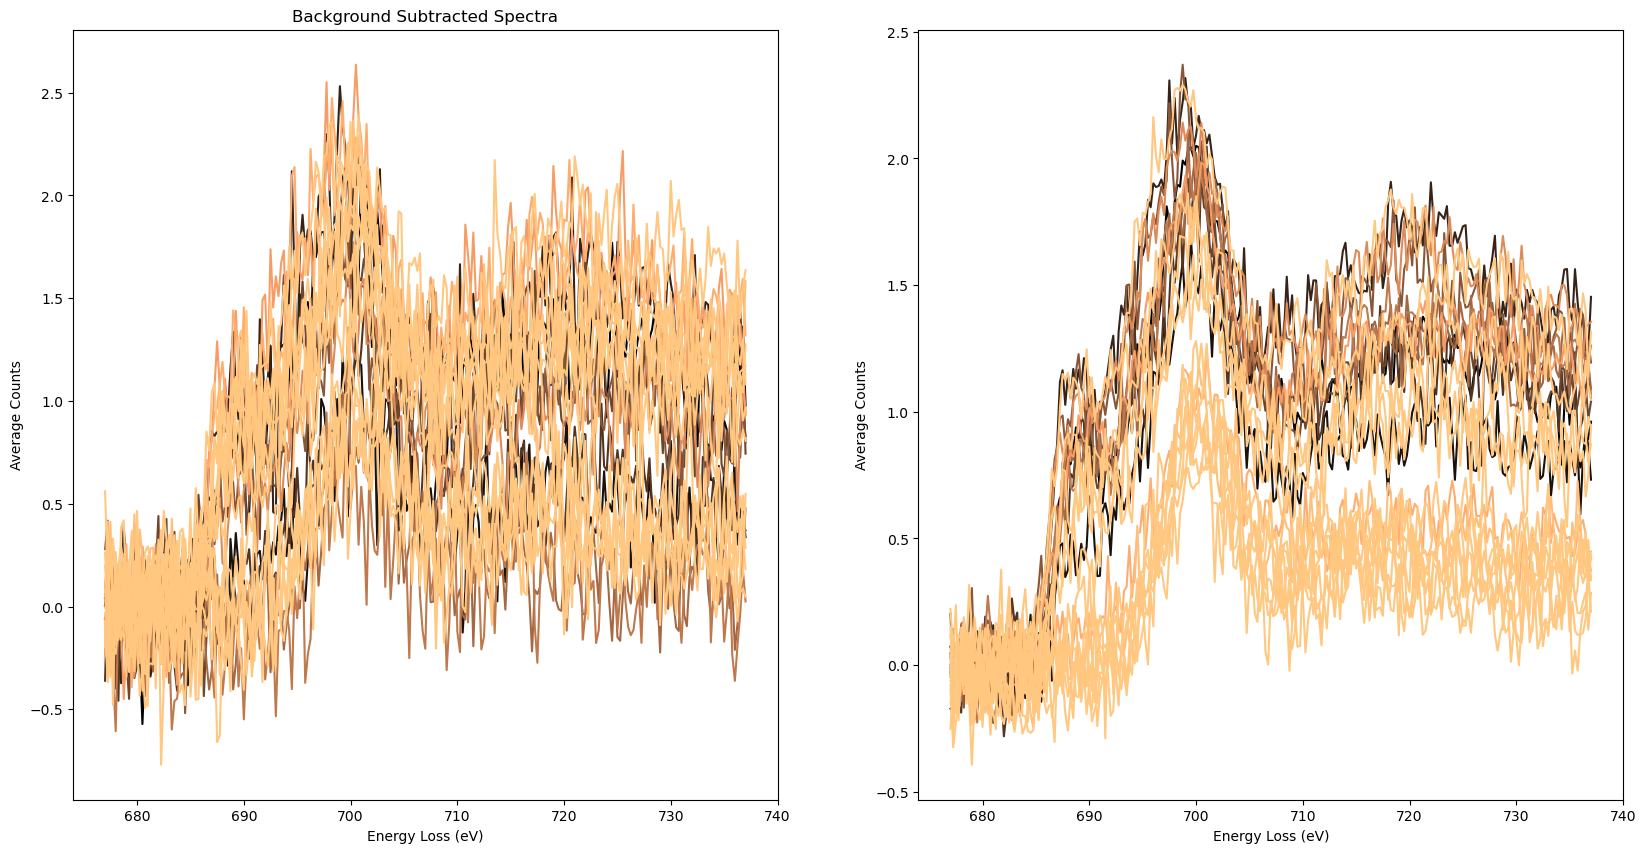

In [91]:
energy_axis_F = energy_axis[ind_F]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))
plotSpectra(ax1, energy_axis_F, backSub_nCr_F_raw, title='Background Subtracted Spectra', )
plotSpectra(ax2, energy_axis_F, backSub_nCr_F_pca)
plt.show()

In [92]:
backSub_nCr_F_raw = (50)*backSub_nCr_F_raw.copy()
backSub_nCr_F_pca = (50)*backSub_nCr_F_pca.copy()

X_train = backSub_nCr_F_raw.copy()
X_train = X_train.reshape(-1, np.shape(X_train)[-1])[:,:-1]
Y_train = backSub_nCr_F_pca.copy()
Y_train = Y_train.reshape(-1, np.shape(Y_train)[-1])[:,:-1]

X_train = np.atleast_3d(X_train).astype('float32')
Y_train = np.atleast_3d(Y_train).astype('float32')

In [97]:
backSub_nCr_F_raw = (50)*backSub_nCr_F_raw
backSub_nCr_F_pca = (50)*backSub_nCr_F_pca

X_train = backSub_nCr_F_raw.reshape(-1, np.shape(backSub_nCr_F_raw)[-1])
Y_train = backSub_nCr_F_pca.reshape(-1, np.shape(backSub_nCr_F_pca)[-1])

X_train = np.atleast_3d(X_train).astype('float32')
Y_train = np.atleast_3d(Y_train).astype('float32')

In [98]:
X_train.shape[1]

241

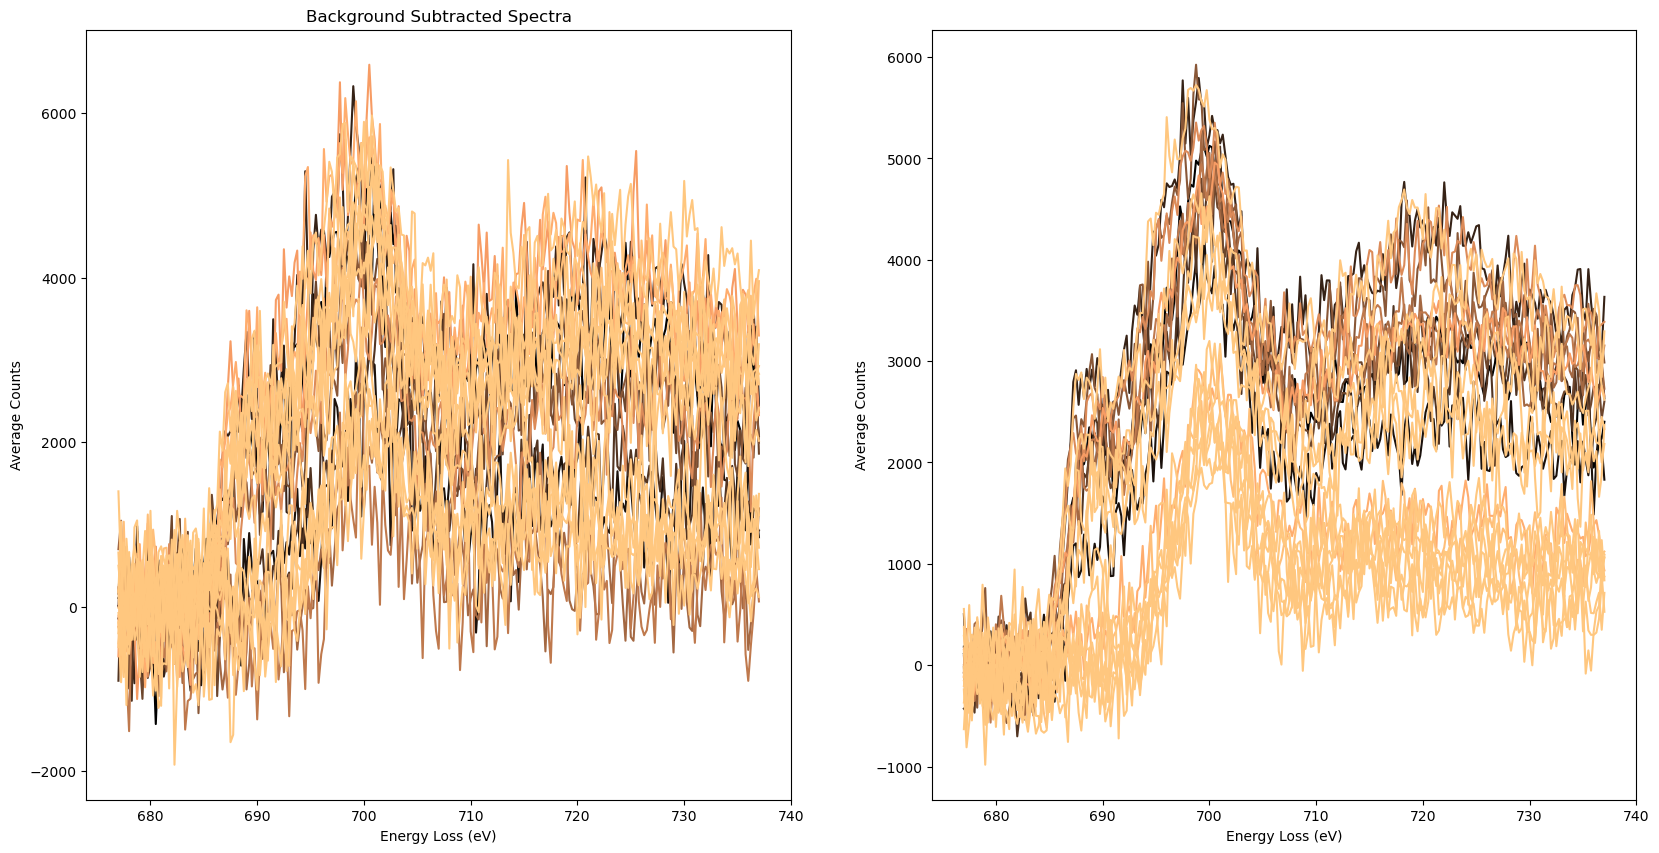

In [100]:
energy_axis_F = energy_axis[ind_F]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))

plotSpectra(ax1, energy_axis_F, X_train, title='Background Subtracted Spectra')
plotSpectra(ax2, energy_axis_F, Y_train)

plt.show()

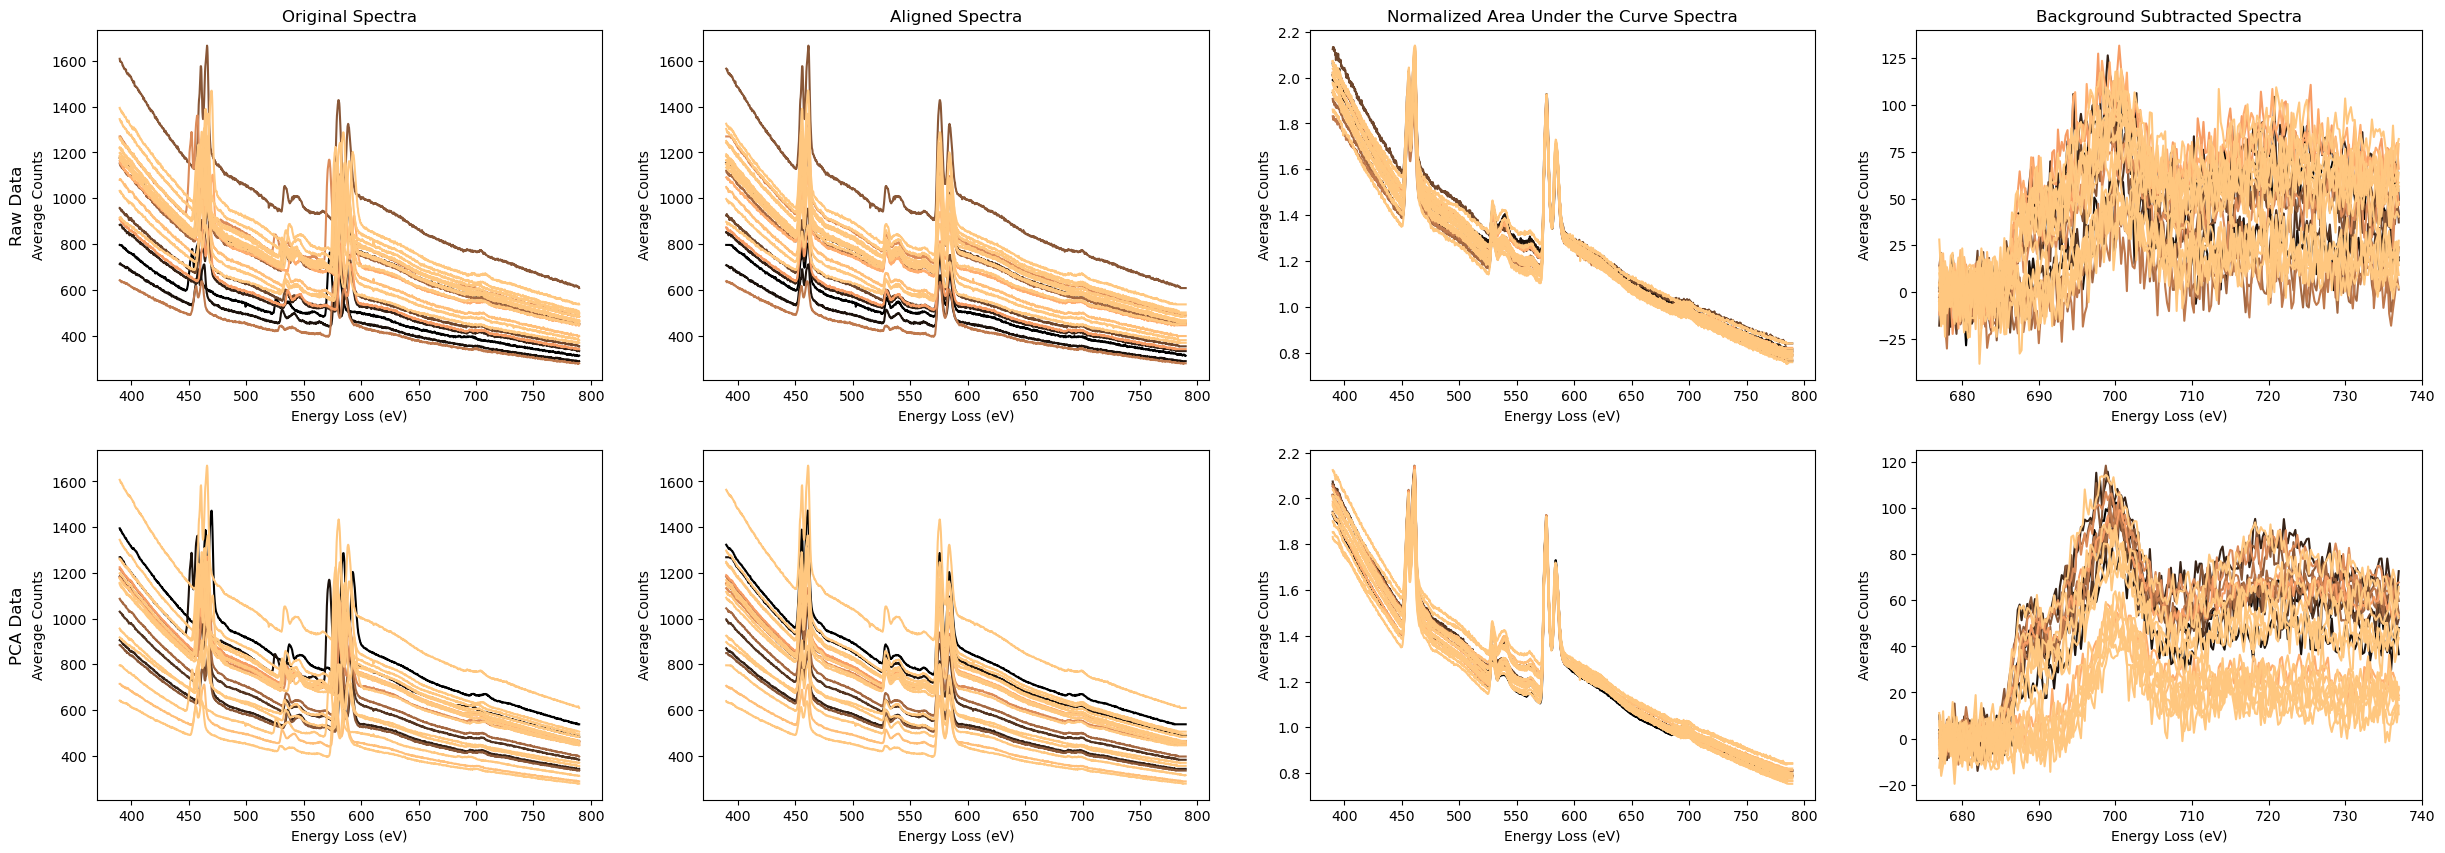

In [94]:
fig, axes = plt.subplots(2, 4, figsize=(30,10))
plotSpectra(axes[0,0], energy_axis, spectra_raw, title='Original Spectra')
plotSpectra(axes[1,0], energy_axis, spectra_pca)
plotSpectra(axes[0,1], energy_axis, aligned_spectra_raw, title='Aligned Spectra')
plotSpectra(axes[1,1], energy_axis, aligned_spectra_pca)
plotSpectra(axes[0,2], energy_axis, aligned_norm_spectra_raw, title='Normalized Area Under the Curve Spectra')
plotSpectra(axes[1,2], energy_axis, aligned_norm_spectra_pca)
plotSpectra(axes[0,3], energy_axis[ind_F], backSub_nCr_F_raw, title='Background Subtracted Spectra')
plotSpectra(axes[1,3], energy_axis[ind_F], backSub_nCr_F_pca)
axes[0,0].annotate('Raw Data', xy=(0, 0.5), xytext=(0 - 5, 0),
                xycoords=axes[0,0].yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)
axes[1,1].annotate('PCA Data', xy=(0, 0.5), xytext=(0 - 5, 0),
                xycoords=axes[1,0].yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)
plt.show()

In [ ]:
fig, ((ax1, ax2), (ax3,ax4)) = plt.subplots(2, 2, figsize=(20,10))
plotSpectra(ax1, energy_axis[ind_F][:-1], X_train, title='Pre-processed Raw Spectra')
plotSpectra(ax2, energy_axis[ind_F][:-1], Y_train, title='Pre-processed PCA Spectra')
plotSpectra(ax3, energy_axis[ind_F][:-1], X_train2, title='Denoised Raw Spectra')
plotSpectra(ax4, energy_axis[ind_F][:-1], Y_train2, title='Reconstructed PCA Spectra')
plt.show()

In [101]:
BATCH_SIZE = 16
EPOCHS = 30
INPUT_SHAPE = (X_train.shape[1], 1)

In [102]:
params={
    'INPUT_SHAPE'   :   INPUT_SHAPE,
    'BATCH_SIZE'    :   BATCH_SIZE,
    'LATENT_SIZE'   :   16,
    'KERNEL_SIZES'  :   [7, 7, 3, 3],
    'FILTER_SIZES'  :   [16, 32, 32, 64],
    'ALPHA'         :   0.3,
    'DROPOUT'       :   0.2,
    'LR'            :   0.0005,
    'RECON_WEIGHT'  :   1.0,
    'KL_WEIGHT'     :   1.0,
    'CNVRG_WEIGHT'  :   1.0,
}

dvae = createDualVAE(params)

dvae.X_encoder.summary()
dvae.Y_encoder.summary()
dvae.decoder.summary()

/home/zensho/miniconda3/envs/eels/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "standard_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 241, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 121, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 121, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 121, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 32)         │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 61, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 61, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 31, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 16, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ z (Dense)                       │ (None, 16)             │        16,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,456 (115.06 KB)

 Trainable params: 29,456 (115.06 KB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 960)            │        16,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 30, 32)         │         6,176 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 60, 32)         │         3,104 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 120, 16)        │         3,600 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_3              │ (None, 240, 1)         │           113 │
│ (Conv1DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,313 (114.50 KB)

 Trainable params: 29,313 (114.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
denhist = dvae.fit(X_train, Y_train,
                   epochs=EPOCHS,
                   batch_size=BATCH_SIZE,
                   verbose=1,
                   shuffle=True,)

In [ ]:
plt.title('YB to YB AEC Model Loss')
plt.plot(denhist.history['loss'], label='Train')
plt.plot(denhist.history['reconstruction_loss'], label='Reconstruction')
plt.plot(denhist.history['kl_loss'], label='KL Loss')
plt.plot(denhist.history['convergence_loss'], label='Convergence')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

In [16]:
hist = denhist

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,5), constrained_layout=True)
plt.suptitle('VAE Model Loss')
ax1.plot(hist.history['loss'], label='Train')
ax1.plot(hist.history['reconstruction_loss'], label='Reconstruction')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(hist.history['kl_loss'], label='KL Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

ax3.plot(hist.history['convergence_loss'], label='convergence')
ax3.set_ylabel('Loss')
ax3.set_xlabel('Epoch')
ax3.legend()

plt.show()

In [ ]:
latent_X = dvae.X_encode(X_train)
latent_Y, _ = dvae.Y_encode(X_train)
recon_X = dvae.denoise(X_train)
recon_Y = dvae.predict(Y_train)

In [ ]:
energy_axis.shape, X_train.shape

In [ ]:
a = energy_axis[ind_F][:-1]
a.shape

In [ ]:
fig, ((ax1, ax2), (ax3,ax4)) = plt.subplots(2, 2, figsize=(20,10))
plotSpectra(ax1, a, X_train, title='Pre-processed Raw Spectra')
plotSpectra(ax2, a, Y_train, title='Pre-processed PCA Spectra')
plotSpectra(ax3, a, recon_X, title='Denoised Raw Spectra')
plotSpectra(ax4, a, recon_Y, title='Reconstructed PCA Spectra')
plt.show()

In [ ]:
plt.plot(a, recon_Y[:,:,0].T)
plt.show()

In [ ]:
plt.plot(a, recon_X[:,:,0].T)
plt.show()

In [34]:
dft_counts = np.load(os.path.join(DATA_DIR, 'MXene_DFT_Data.npy'))
dft_labels = np.load(os.path.join(DATA_DIR, 'MXene_DFT_Labels.npy'))

In [ ]:
gt_x = dft_counts
gt_label_old = dft_labels

latent_dim = latent_X.shape[1]
n=100

gt_z_mean, gt_z_var = dvae.Y_encoder.predict(gt_x)
gt_z = np.zeros((gt_x.shape[0]*n, latent_dim))
gt_label = np.zeros((gt_x.shape[0]*n), dtype=int)

for i in range(gt_x.shape[0]):
    gt_z[i*n:(i*n)+n] = np.random.normal(gt_z_mean[i], np.exp(0.5 * gt_z_var[i]), (n, latent_dim))
    gt_label[i*n:(i*n)+n] = gt_label_old[i]

gt_pred = dvae.decoder.predict(gt_z)

In [ ]:
latent_DF = pd.DataFrame(np.concatenate((latent_X, gt_z)))
latent_DF['label'] = np.concatenate((np.ones(24*570) * 4, gt_label))
latent_DF.shape

In [ ]:
g = sn.pairplot(latent_DF, hue='label', palette='tab10', corner=True)
# g.map_diag(sn.histplot)
# g.map_offdiag(sn.scatterplot)
plt.show()

In [50]:
energy_axis = energy_axis[ind_F][:-1]

In [ ]:
c_map = [mpl.colormaps['viridis'](255), mpl.colormaps['viridis'](127),mpl.colormaps['viridis'](63), mpl.colormaps['viridis'](0)]
L1, L2 = 14, 15

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,5))

for i in range(gt_x.shape[0]):
  ax1.plot(energy_axis,gt_x[i], c=c_map[gt_label_old[i]])

ax2.scatter(gt_z[:,L1], gt_z[:,L2], c=gt_label[:])

for i in range(gt_pred.shape[0]):
    ax3.plot(energy_axis,gt_pred[i], c=c_map[gt_label[i]])

plt.show()

In [ ]:
gt_z_sel = np.array([gt_z[:,L1], gt_z[:,L2]]).T
latent_Y_sel = np.array([latent_Y[:,L1], latent_Y[:,L2]]).T
gt_z_sel.shape, gt_z.shape, gt_label.shape

In [53]:
gpc = GaussianProcessClassifier().fit(gt_z_sel, gt_label)

gpc_class_aec = np.zeros_like((Y_train.shape[0], gt_label[-1]))
gpc_class_aec = gpc.predict(latent_Y_sel)

In [ ]:
plt.figure(figsize=(12,10))
plt.scatter(gt_z[:,L1], gt_z[:,L2], c=gt_label, marker='.')
plt.scatter(latent_Y[:,L1], latent_Y[:,L2], c=gpc_class_aec, marker='s', edgecolors='k')
plt.xlabel("Latent Var [0]")
plt.ylabel("Latent Var [1]")
plt.title('Means Classified via GPC')
plt.show()

In [ ]:
T = ['Initial', '200 C', '300 C', '400 C', '500 C', '600 C', '700 C', '800 C']
AList = ['Area 1', 'Area 3', 'Area 4']
plot_SI_class(gpc_class_aec, xlabels=T, ylabels=AList)
plt.show()